In [21]:
# imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [22]:
# load the data
data = pd.read_csv('data.csv')
data.head()

,statename,year,month,spend apparel and accessories,spend accommodation and food services,"spend arts, entertainment, and recreation",spend all,spend general merchandise + apparel,spend durable goods,spend general merchandise,...,hospitalized_rate,day,time retail and recreation,time grocery and pharmacy,time parks,time transit stations,time workplaces,time residential,time away from home,emp recovered
0,Alabama,2020,1,0.0000,-1.910000e-09,0.0000,0.0000,-2.880000e-08,3.280000e-08,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,Alabama,2020,2,-0.0438,2.160000e-02,0.0643,0.0278,2.020000e-02,1.250000e-02,0.0782,...,NaN,29.0,0.0900,0.0414,0.191,0.1070,0.010,-0.00571,0.00855,True
2,Alabama,2020,3,-0.3510,-3.800000e-01,-0.3730,-0.0898,-1.460000e-01,-3.850000e-02,0.0646,...,0.101591,31.0,-0.3340,-0.0643,0.180,-0.2340,-0.344,0.13100,-0.15900,False
3,Alabama,2020,4,-0.5350,-6.060000e-01,-0.6520,-0.2290,-3.190000e-01,1.530000e-02,-0.0916,...,7.704000,30.0,-0.2400,-0.0300,0.143,-0.2300,-0.347,0.12100,-0.14800,False
4,Alabama,2020,5,-0.1820,-3.820000e-01,-0.4720,-0.1010,-7.270000e-02,1.720000e-01,0.0279,...,8.569677,31.0,-0.0914,0.0314,0.373,-0.0371,-0.236,0.08290,-0.09430,False


In [23]:
data.columns

Index(['statename', 'year', 'month', 'spend apparel and accessories',
       'spend accommodation and food services',
       'spend arts, entertainment, and recreation', 'spend all',
       'spend general merchandise + apparel', 'spend durable goods',
       'spend general merchandise', 'spend grocery and food stores',
       'spend health care and social assistance',
       'spend home improvement centers', 'spend other in-person services',
       'spend non-durable goods', 'spend remote services',
       'spend transportation and warehousing', 'spend all_incmiddle',
       'spend all q1', 'spend all q2', 'spend all q3', 'spend all q4',
       'spend in-person services', 'spend retail excluding grocery',
       'spend retail including grocery', 'day_endofweek', 'emp all', 'emp q1',
       'emp q2', 'emp q3', 'emp q4', 'emp inc middle', 'emp inc below_median',
       'emp inc above median', 'emp trade_transport utilities',
       'emp professional business_services', 'emp education hea

### 1. data prep

In [24]:
# select features and target
feat = ['spend all', 'spend arts, entertainment, and recreation', # spend features
        'case_rate', 'death_rate', 'hospitalized_rate', # covid features, 
        ]
target = 'emp recovered'

# see missing values in features and target
print(f'num missing in cols: \n{data[feat + [target]].isnull().sum()}')

# drop rows with missing values
data = data.dropna(subset=feat + [target])

# store statenames for mapping later
state_names = data['statename']

# define X and y
X = data[feat]
y = data[target].astype(int)

X.head()


num missing in cols: 
spend all                                      0
spend arts, entertainment, and recreation      0
case_rate                                    139
death_rate                                   139
hospitalized_rate                            130
emp recovered                                239
dtype: int64


,spend all,"spend arts, entertainment, and recreation",case_rate,death_rate,hospitalized_rate
2,-0.08980,-0.373,3.848895,0.017158,0.101591
3,-0.22900,-0.652,72.970000,2.257533,7.704000
4,-0.10100,-0.472,224.387097,8.786129,8.569677
5,-0.02560,-0.302,504.966667,15.463333,16.526667
6,0.00473,-0.326,1166.548387,24.080645,32.906452


### 2. define train and test sets

In [25]:
# test set is all data from january 2025 (five years after the start of the pandemic)
test_mask = (data['year'] == 2025) & (data['month'] == 1)
X_test = X[test_mask]
y_test = y[test_mask]
states_test = state_names[test_mask]

# train set is all other data
X_train = X[~test_mask]
y_train = y[~test_mask]
states_train = state_names[~test_mask]

# print lengths of train and test sets
print(f'train set length: {len(X_train)}')
print(f'test set length: {len(X_test)}')

train set length: 3133
test set length: 50


### 3. initialize and fit the LDA model

In [26]:
# initialize LDA
lda = LinearDiscriminantAnalysis()

# fit LDA model
lda.fit(X_train, y_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [27]:
y_pred = lda.predict(X_test)

# Step 6: Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.68

Confusion matrix:
 [[33  2]
 [14  1]]

Classification report:
               precision    recall  f1-score   support

           0       0.70      0.94      0.80        35
           1       0.33      0.07      0.11        15

    accuracy                           0.68        50
   macro avg       0.52      0.50      0.46        50
weighted avg       0.59      0.68      0.60        50



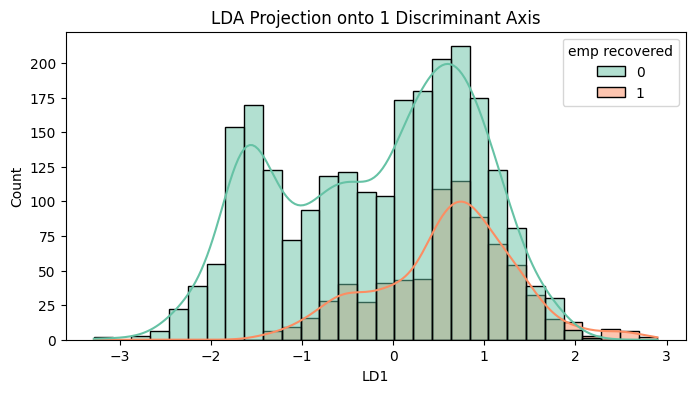

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

X_lda = lda.transform(X)
plt.figure(figsize=(8,4))
sns.histplot(x=X_lda[:, 0], hue=y, bins=30, kde=True, palette="Set2")
plt.title("LDA Projection onto 1 Discriminant Axis")
plt.xlabel("LD1")
plt.show()
